# CCS 230 – Final Project
## Data Mining for Heart Disease Pattern Discovery and Risk Prediction

**Group Members:**
- Shane D. Canabo
- Myrrhea Belle B. Junsay
- Kyla Elijah C. Ramiro
- Meagelleine Rose S. Sionosa
- Athena S. Villarin


---
## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
%matplotlib inline

---
# PHASE 1: Business & Data Understanding

## 1.1 Load Dataset

In [2]:
df = pd.read_csv('data/heart.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 1.2 Descriptive Statistics

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
# Check for missing values
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
# Target distribution
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

## 1.3 Visualizations

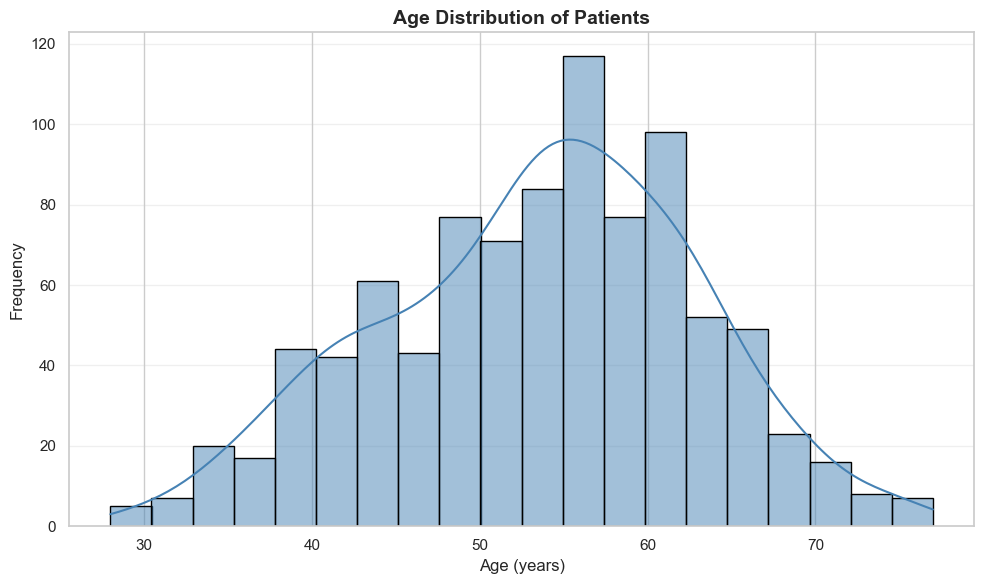

Age Statistics:
  Mean: 53.5 years
  Median: 54.0 years
  Std Dev: 9.4 years
  Range: 28-77 years


In [7]:
# TODO: Age distribution
# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', bins=20, kde=True, color='steelblue', edgecolor='black')
plt.title('Age Distribution of Patients', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print(f'Age Statistics:')
print(f'  Mean: {df["Age"].mean():.1f} years')
print(f'  Median: {df["Age"].median():.1f} years')
print(f'  Std Dev: {df["Age"].std():.1f} years')
print(f'  Range: {df["Age"].min()}-{df["Age"].max()} years')

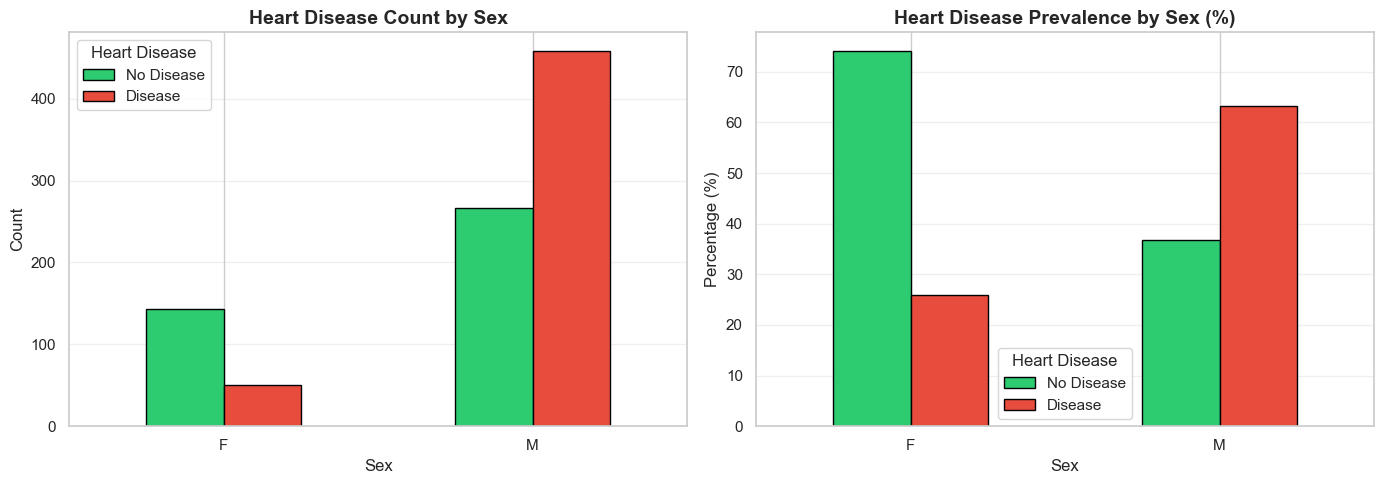

Heart Disease by Sex:
HeartDisease    0    1
Sex                   
F             143   50
M             267  458

Heart Disease Prevalence by Sex (%):
HeartDisease      0      1
Sex                       
F             74.09  25.91
M             36.83  63.17


In [8]:
# TODO: Heart Disease count by Sex
# Heart Disease count by Sex
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Stacked count plot
sex_disease = pd.crosstab(df['Sex'], df['HeartDisease'])
sex_disease.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Heart Disease Count by Sex', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sex', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(['No Disease', 'Disease'], title='Heart Disease')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Proportion/percentage plot
sex_disease_pct = pd.crosstab(df['Sex'], df['HeartDisease'], normalize='index') * 100
sex_disease_pct.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Heart Disease Prevalence by Sex (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sex', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(['No Disease', 'Disease'], title='Heart Disease')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print('Heart Disease by Sex:')
print(sex_disease)
print('\nHeart Disease Prevalence by Sex (%):')
print(sex_disease_pct.round(2))

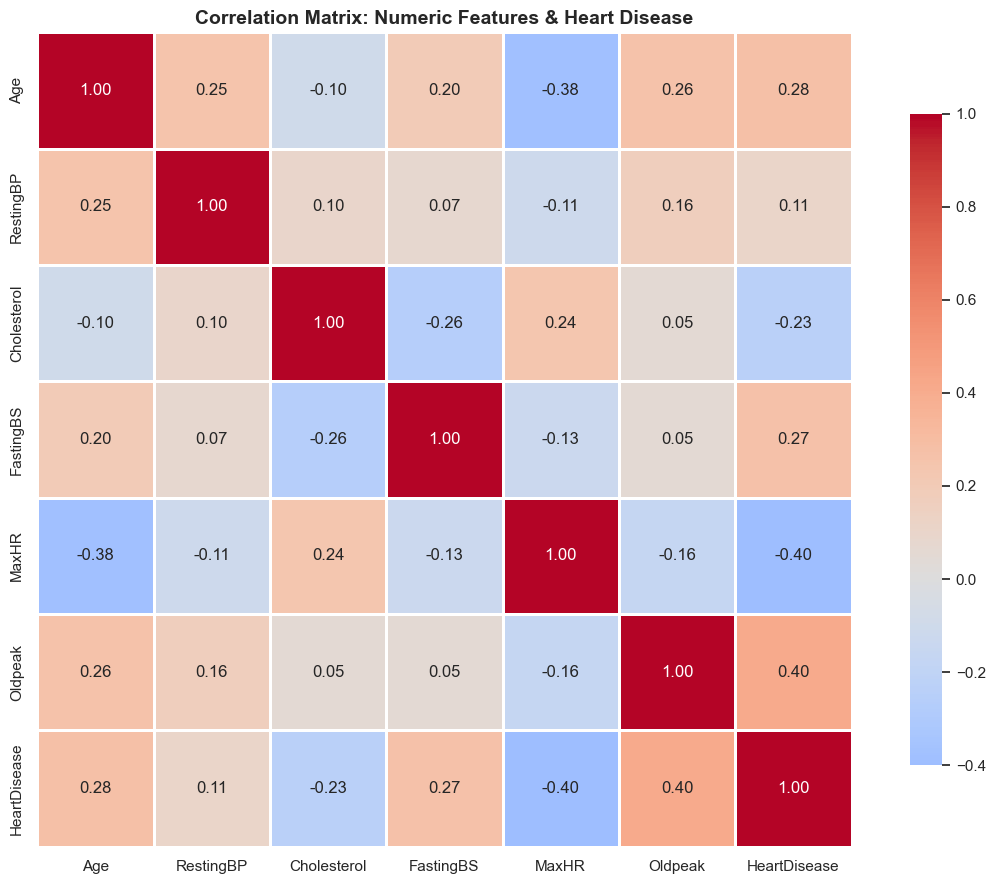


Correlations with Heart Disease (sorted by strength):
HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64

Strong Correlations with Heart Disease (|r| > 0.3):
Oldpeak    0.403951
MaxHR     -0.400421
Name: HeartDisease, dtype: float64


In [9]:
# TODO: Correlation heatmap (numeric columns)
# Correlation heatmap (numeric columns)
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Create figure
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Numeric Features & Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Extract correlations with HeartDisease (sorted by absolute value)
print('\nCorrelations with Heart Disease (sorted by strength):')
disease_correlations = correlation_matrix['HeartDisease'].sort_values(ascending=False)
print(disease_correlations)

# Highlight strong correlations (|r| > 0.3)
print('\nStrong Correlations with Heart Disease (|r| > 0.3):')
strong_corr = disease_correlations[(abs(disease_correlations) > 0.3) & (disease_correlations.index != 'HeartDisease')]
print(strong_corr.sort_values(ascending=False))

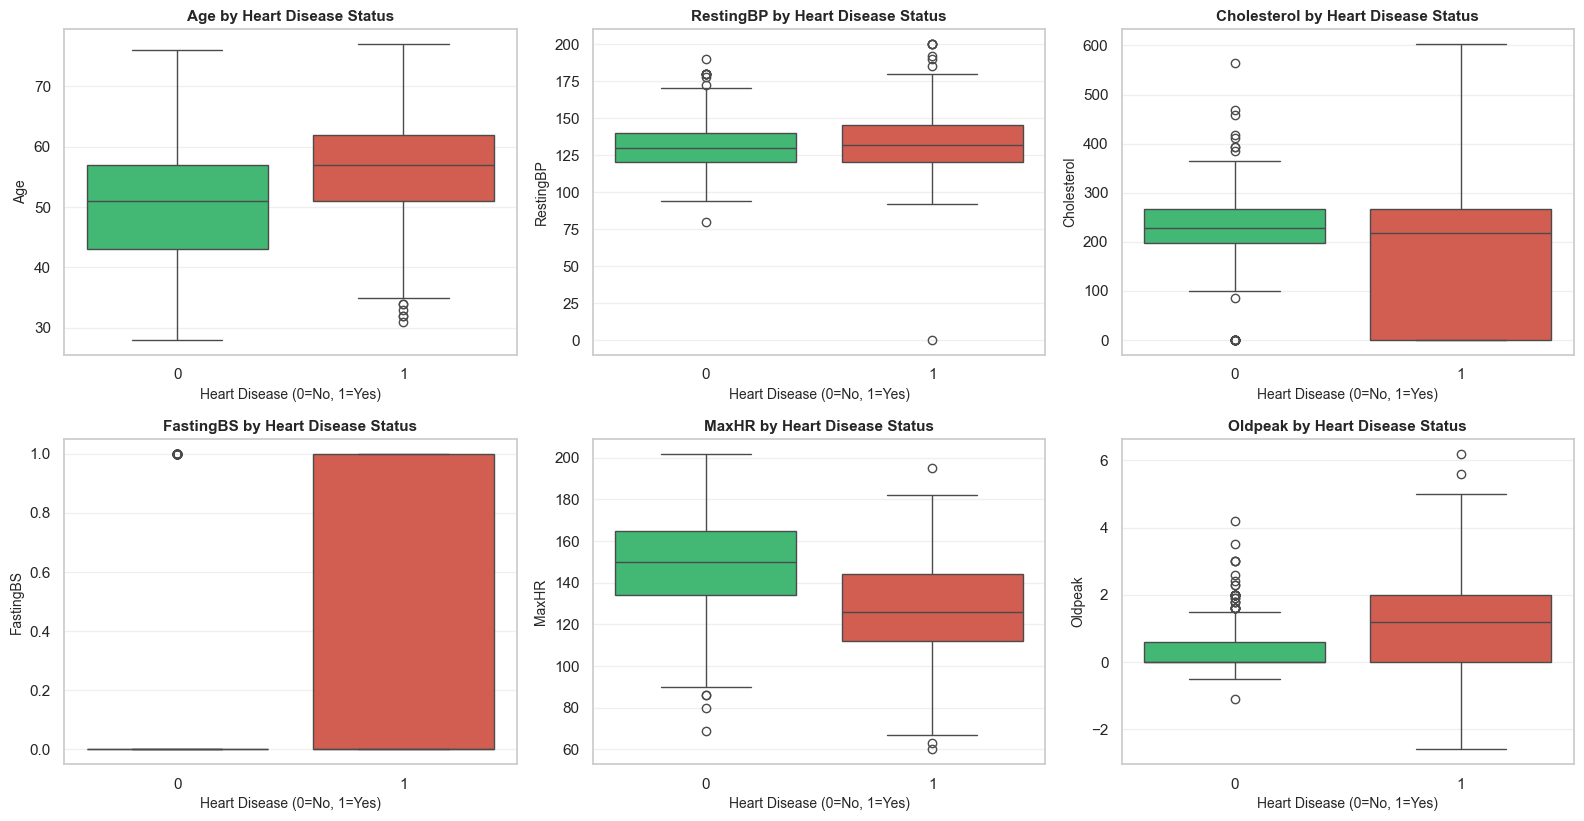

Boxplot Analysis: Median differences between disease/no-disease groups



In [10]:
# TODO: Additional visualizations (boxplots, bar charts per categorical feature)
# Additional visualizations (boxplots, bar charts per categorical feature)

# 1. BOXPLOTS: Continuous features by Heart Disease status
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('HeartDisease')  # Remove target from features

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    sns.boxplot(data=df, x='HeartDisease', y=feature, ax=axes[idx], palette=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{feature} by Heart Disease Status', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Heart Disease (0=No, 1=Yes)', fontsize=10)
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide unused subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print('Boxplot Analysis: Median differences between disease/no-disease groups\n')


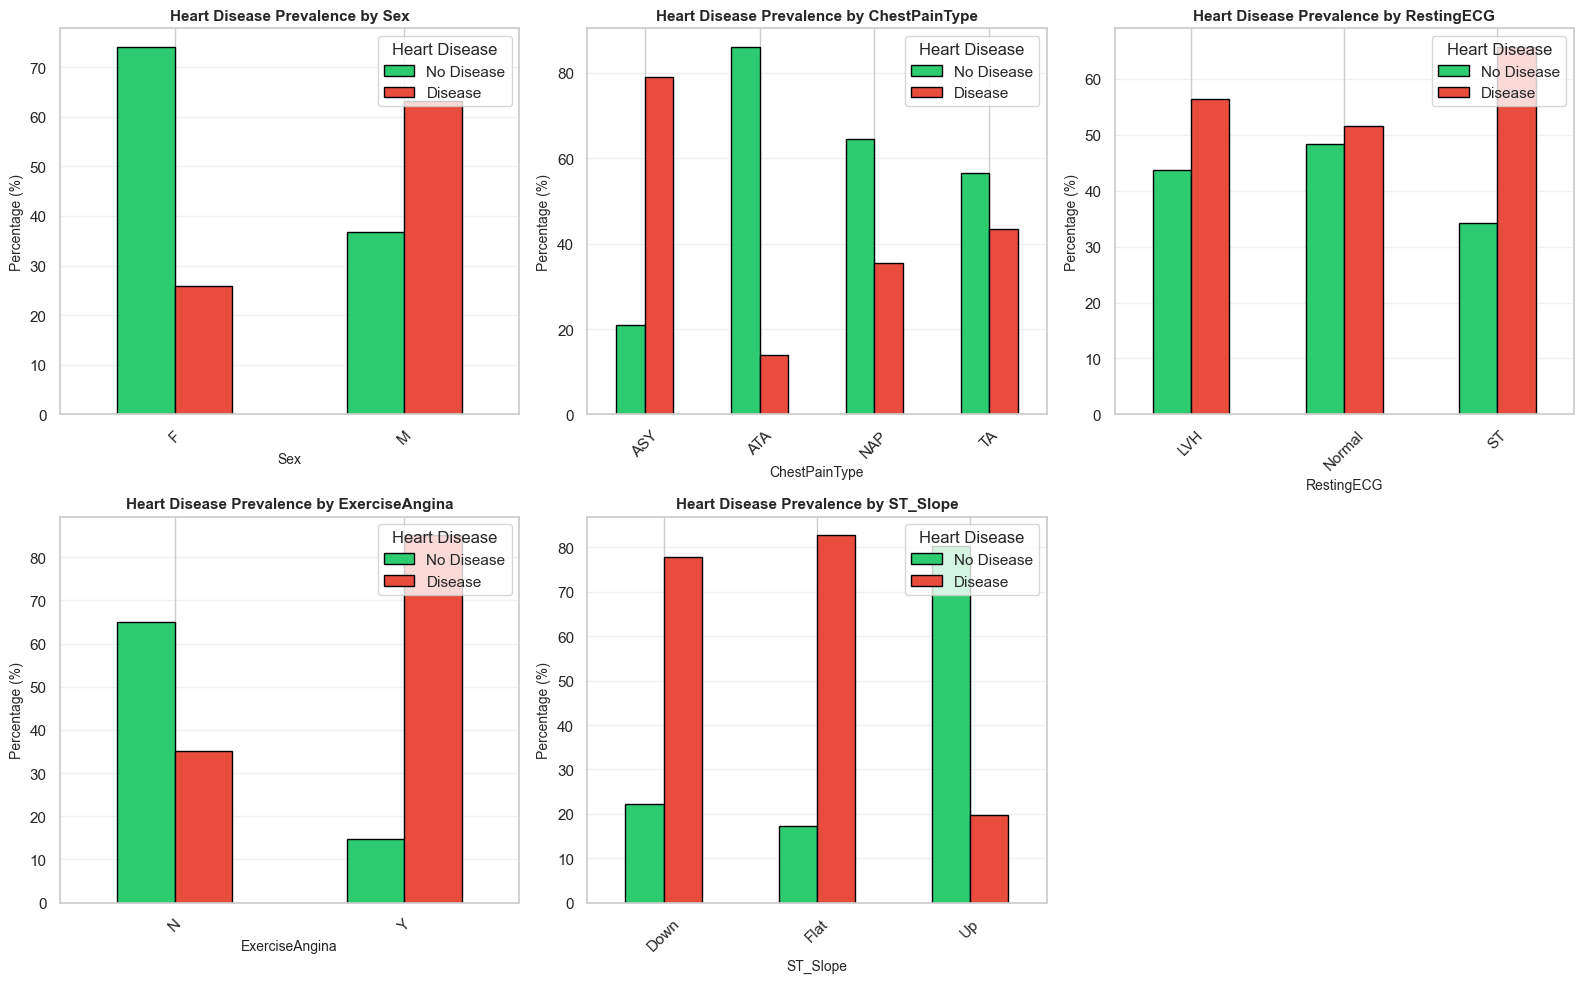

In [11]:
# 2. BAR CHARTS: Categorical features by Heart Disease
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    # Create crosstab and normalize
    cat_disease = pd.crosstab(df[feature], df['HeartDisease'], normalize='index') * 100
    cat_disease.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[idx].set_title(f'Heart Disease Prevalence by {feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Percentage (%)', fontsize=10)
    axes[idx].legend(['No Disease', 'Disease'], title='Heart Disease', loc='upper right')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide unused subplots
for idx in range(len(categorical_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
# 3. SUMMARY STATISTICS
print('\n' + '='*60)
print('CATEGORICAL FEATURE BREAKDOWN')
print('='*60)
for feature in categorical_features:
    print(f'\n{feature}:')
    cat_summary = pd.crosstab(df[feature], df['HeartDisease'], margins=True)
    print(cat_summary)
    
    # Disease prevalence per category
    cat_pct = pd.crosstab(df[feature], df['HeartDisease'], normalize='index') * 100
    print(f'\nDisease Prevalence (%):\n{cat_pct[1].round(2)}')

print('\n' + '='*60)
print('NUMERIC FEATURE STATISTICS BY DISEASE STATUS')
print('='*60)
for feature in numeric_features:
    print(f'\n{feature}:')
    print(df.groupby('HeartDisease')[feature].agg(['mean', 'median', 'std', 'min', 'max']).round(2))


CATEGORICAL FEATURE BREAKDOWN

Sex:
HeartDisease    0    1  All
Sex                        
F             143   50  193
M             267  458  725
All           410  508  918

Disease Prevalence (%):
Sex
F    25.91
M    63.17
Name: 1, dtype: float64

ChestPainType:
HeartDisease     0    1  All
ChestPainType               
ASY            104  392  496
ATA            149   24  173
NAP            131   72  203
TA              26   20   46
All            410  508  918

Disease Prevalence (%):
ChestPainType
ASY    79.03
ATA    13.87
NAP    35.47
TA     43.48
Name: 1, dtype: float64

RestingECG:
HeartDisease    0    1  All
RestingECG                 
LVH            82  106  188
Normal        267  285  552
ST             61  117  178
All           410  508  918

Disease Prevalence (%):
RestingECG
LVH       56.38
Normal    51.63
ST        65.73
Name: 1, dtype: float64

ExerciseAngina:
HeartDisease      0    1  All
ExerciseAngina               
N               355  192  547
Y                5

---
# PHASE 2: Data Preparation & Modeling

## 2.1 Data Cleaning & Preparation

In [ ]:
# TODO: One-Hot Encoding for categorical features


In [ ]:
# TODO: Discretization / Binning of continuous features (for Association Rule Mining)


## 2.2 Association Rule Mining

In [ ]:
# TODO: Prepare one-hot encoded transaction dataset for Apriori


In [ ]:
# TODO: Run Apriori algorithm


In [ ]:
# TODO: Generate association rules and filter for HeartDisease as consequent


In [ ]:
# TODO: Display top rules sorted by confidence/lift


## 2.3 Classification Modeling

In [ ]:
# TODO: Define features (X) and target (y), then train-test split


### 2.3.1 Decision Tree

In [ ]:
# TODO: Train Decision Tree


In [ ]:
# TODO: Plot Decision Tree


In [ ]:
# TODO: Extract readable rules from Decision Tree


### 2.3.2 Random Forest

In [ ]:
# TODO: Train Random Forest


In [ ]:
# TODO: Plot Feature Importance


## 2.4 K-Means Clustering (Patient Archetypes)

In [ ]:
# TODO: Run K-Means and identify patient cluster profiles


---
# PHASE 3: Evaluation & Insight Generation

## 3.1 Model Evaluation

In [ ]:
# TODO: Confusion Matrix – Decision Tree


In [ ]:
# TODO: Confusion Matrix – Random Forest


In [ ]:
# TODO: Compare Accuracy, Precision, Recall, F1 of both models


## 3.2 Clinical Insights & Discussion

*(TODO: Write discussion here — translate findings into clinical language for the hospital board)*

## 3.3 Strategic Recommendation

*(TODO: State which model to deploy, why, and potential risks)*